# Notebook 02: Feature Engineering

In this notebook, we stitch together the pipeline for processing our ML features:
1. **Load EEG** continuously -> Map to Epochs via events.tsv.
2. **Artifact Rejection** -> Drop noisy trials > ±100 µV.
3. **Extract EEG Features** -> Calculate Hjorth Parameters and Band Powers across frequency bands on clean epochs.
4. **Extract Audio Features** -> Get MFCC and Chroma coefficients from the `.mp3` files.
5. **Combine** -> Merge the EEG dataframe with the acoustic dataframe to form the final input `X`.

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Ensure our src modules can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from eeg_utils import load_and_epoch_eeg, reject_artifacts, perform_ica
from features import extract_eeg_features_from_epochs
from audio_utils import extract_audio_features

base_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Base path: {base_path}")

Base path: /home/trainerblue/Documents/daly-comp-analysis


### 1. EEG Pipeline: Epoching & Artifact Rejection

--- STAGE 1: RAW UNFILTERED EEG ---
Loading pure raw data to see the DC Drift (slowly wandering lines) that caused 100% of our epochs to drop earlier.
Using matplotlib as 2D backend.


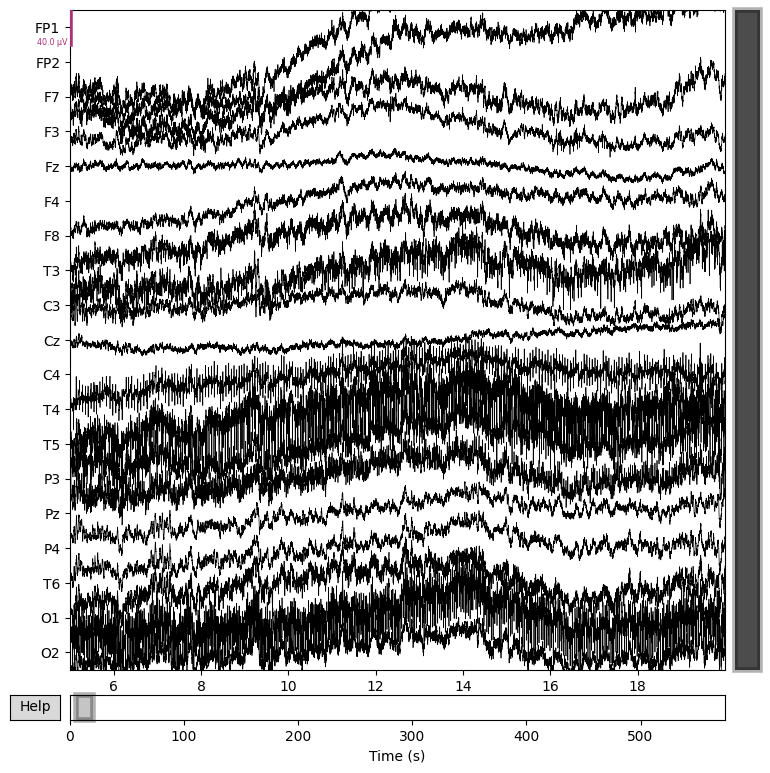


--- STAGE 2: FILTERED EEG ---
We apply a 0.5 to 45 Hz bandpass filter. The lines snap to the center (0), but huge eye-blink spikes remain on FP1/FP2.


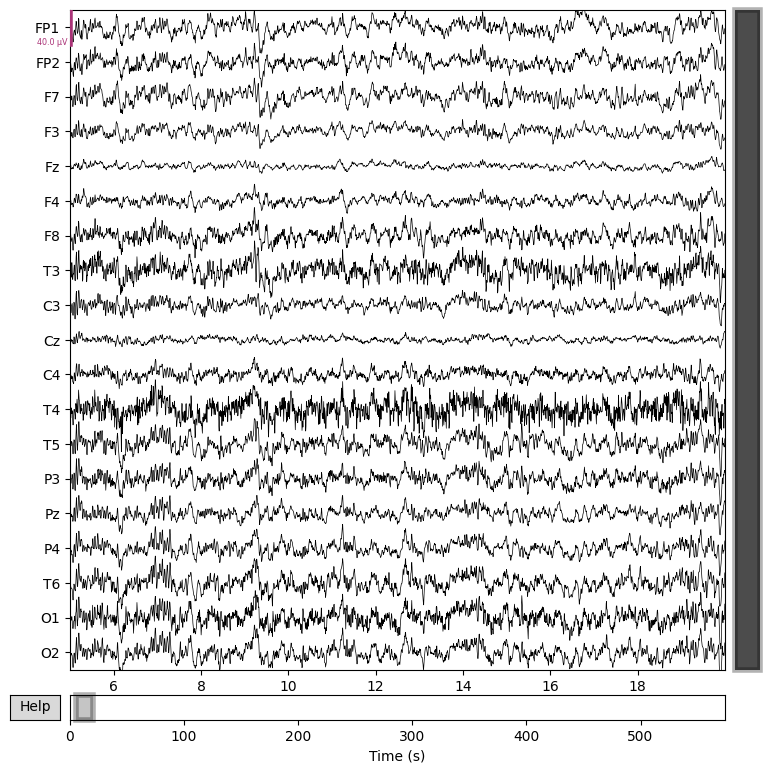


--- STAGE 3: EPOCHING & ICA ---
Slicing into 15-second music clips and running Independent Component Analysis (ICA) to subtract out the eye blinks mathematically.
-> Loaded 10 epochs.
-> Applied ICA ocular artifact subtraction.

--- STAGE 4: AMPLITUDE REJECTION & FINAL CLEAN EPOCHS ---
Dropping remaining physical anomalies (> 300 µV peak-to-peak) and yielding the final pure brain signals for ML.
    Rejecting  epoch based on EEG : ['FP1']
    Rejecting  epoch based on EEG : ['FP1', 'FP2']
    Rejecting  epoch based on EEG : ['FP1', 'FP2', 'F8']
3 bad epochs dropped
-> 7 epochs remaining after artifact rejection.

This represents the final clear data going directly into our feature extraction pipeline:


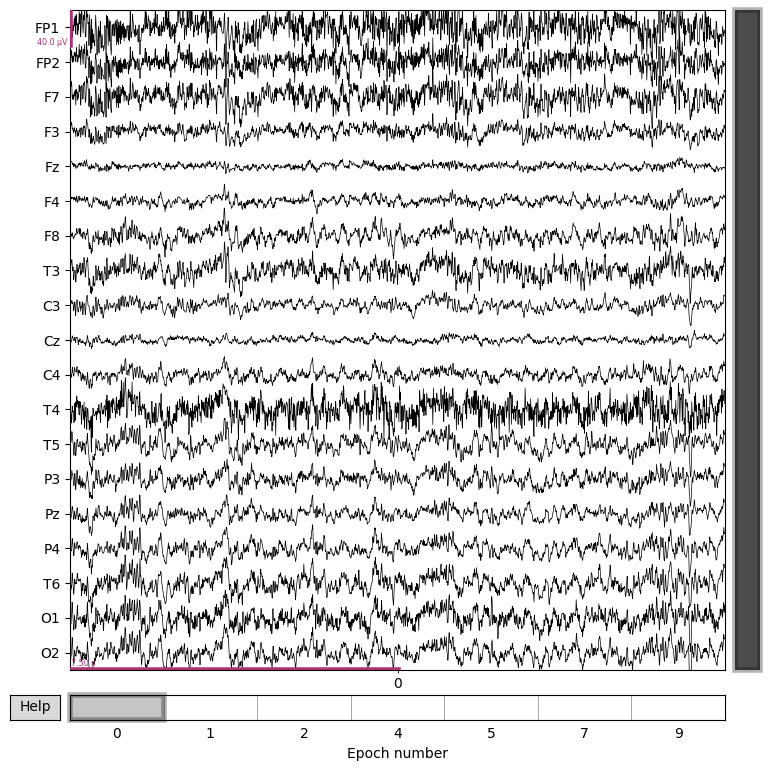

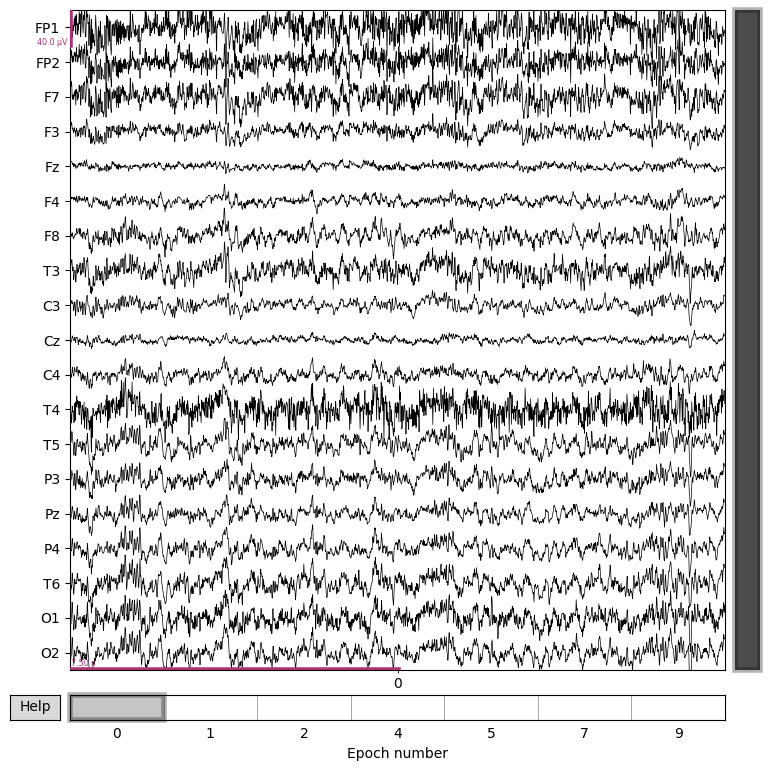

In [2]:
import builtins
import mne

sub1_edf = os.path.join(base_path, 'data', 'sub-01', 'eeg', 'sub-01_task-run2_eeg.edf')
sub1_events = os.path.join(base_path, 'data', 'sub-01', 'eeg', 'sub-01_task-run2_events.tsv')

print("--- STAGE 1: RAW UNFILTERED EEG ---")
print("Loading pure raw data to see the DC Drift (slowly wandering lines) that caused 100% of our epochs to drop earlier.")
raw_vis = mne.io.read_raw_edf(sub1_edf, preload=True, verbose='ERROR')
raw_vis.set_channel_types({ch: 'eeg' for ch in raw_vis.ch_names if ch != 'STI 014'})
raw_vis.plot(duration=15.0, start=5.0, n_channels=19)

print("\n--- STAGE 2: FILTERED EEG ---")
print("We apply a 0.5 to 45 Hz bandpass filter. The lines snap to the center (0), but huge eye-blink spikes remain on FP1/FP2.")
raw_vis.filter(l_freq=0.5, h_freq=45.0, verbose='ERROR')
raw_vis.plot(duration=15.0, start=5.0, n_channels=19)

print("\n--- STAGE 3: EPOCHING & ICA ---")
print("Slicing into 15-second music clips and running Independent Component Analysis (ICA) to subtract out the eye blinks mathematically.")
# load_and_epoch_eeg already applies the 0.5-45Hz filter internally
epochs = load_and_epoch_eeg(sub1_edf, sub1_events, tmin=0.0, tmax=15.0)
print(f"-> Loaded {len(epochs)} epochs.")
ica_epochs = perform_ica(epochs)
print("-> Applied ICA ocular artifact subtraction.")

print("\n--- STAGE 4: AMPLITUDE REJECTION & FINAL CLEAN EPOCHS ---")
print("Dropping remaining physical anomalies (> 300 µV peak-to-peak) and yielding the final pure brain signals for ML.")
clean_epochs = reject_artifacts(ica_epochs, threshold_uv=300)
print(f"-> {len(clean_epochs)} epochs remaining after artifact rejection.")

print("\nThis represents the final clear data going directly into our feature extraction pipeline:")
clean_epochs.plot(n_epochs=1, n_channels=19)

### 2. Extract EEG Features

In [3]:
# 3. Extract Hjorth and Band Powers for all remaining clean epochs
eeg_features_list = extract_eeg_features_from_epochs(clean_epochs)
eeg_df = pd.DataFrame(eeg_features_list)

display(eeg_df.head())

,track_id,FP1_hjorth_mobility,FP1_hjorth_complexity,FP1_delta_power,FP1_theta_power,FP1_alpha_power,FP1_beta_power,FP1_gamma_power,FP2_hjorth_mobility,FP2_hjorth_complexity,...,O1_alpha_power,O1_beta_power,O1_gamma_power,O2_hjorth_mobility,O2_hjorth_complexity,O2_delta_power,O2_theta_power,O2_alpha_power,O2_beta_power,O2_gamma_power
0,62,0.134352,1.729703,3.407279e-11,1.162846e-11,1.700672e-11,3.895831e-11,2.944737e-11,0.132419,1.754594,...,6.076842e-12,1.346509e-11,6.810825e-12,0.067440,2.958475,3.651759e-11,1.490805e-11,6.281470e-12,9.204183e-12,2.303758e-12
1,163,0.135765,1.726686,4.352424e-11,1.117196e-11,2.338304e-11,4.184723e-11,3.340625e-11,0.125188,1.862795,...,5.481278e-12,1.193575e-11,6.818107e-12,0.070431,2.788148,2.893380e-11,1.871259e-11,5.397709e-12,9.057570e-12,2.279898e-12
2,160,0.090367,2.529424,9.784519e-11,2.023138e-11,2.085790e-11,3.973028e-11,2.533906e-11,0.067383,3.375198,...,7.319568e-12,1.473576e-11,5.583871e-12,0.064510,2.883772,3.414789e-11,1.841163e-11,7.486629e-12,1.253482e-11,2.052162e-12
3,140,0.084414,2.616659,1.102087e-10,2.152337e-11,2.374664e-11,4.068033e-11,2.173467e-11,0.067030,3.318520,...,8.365996e-12,1.578352e-11,5.600752e-12,0.063335,2.890941,3.901077e-11,1.630755e-11,1.041343e-11,1.326304e-11,2.034140e-12
4,113,0.074725,3.117129,1.126839e-10,1.598543e-11,2.688764e-11,3.082733e-11,2.540161e-11,0.059408,3.947400,...,5.842765e-12,1.269671e-11,7.561010e-12,0.061584,3.379266,5.062954e-11,1.500557e-11,5.813428e-12,8.979917e-12,2.997581e-12


### 3. Audio Pipeline & Merging

In [6]:
# 4. Extract Acoustic Features for an example MP3
# Since we are using "Run 2" for the EEG epoching above, we need to pick a track that actually 
# played during Run 2. Track 62 (062.mp3) is one of the tracks in Run 2.
example_audio_path = os.path.join(base_path, 'data', 'music', 'Set1', 'Set1', '062.mp3')

if os.path.exists(example_audio_path):
    audio_feat = extract_audio_features(example_audio_path)
    audio_feat['track_id'] = 62
    audio_df = pd.DataFrame([audio_feat])
    
    # 5. Merge Features based on Track ID
    combined_df = pd.merge(eeg_df, audio_df, on='track_id', how='inner')
    print(f"Combined Feature Matrix shape: {combined_df.shape}")
    display(combined_df.head())
else:
    print("Example audio path not found. Please ensure the MP3s are extracted.")

Combined Feature Matrix shape: (1, 200)


,track_id,FP1_hjorth_mobility,FP1_hjorth_complexity,FP1_delta_power,FP1_theta_power,FP1_alpha_power,FP1_beta_power,FP1_gamma_power,FP2_hjorth_mobility,FP2_hjorth_complexity,...,chroma_9_mean,chroma_9_std,chroma_10_mean,chroma_10_std,chroma_11_mean,chroma_11_std,chroma_12_mean,chroma_12_std,spectral_centroid_mean,rms_energy_mean
0,62,0.134352,1.729703,3.407279e-11,1.162846e-11,1.700672e-11,3.895831e-11,2.944737e-11,0.132419,1.754594,...,0.293128,0.228263,0.317961,0.258444,0.429813,0.30655,0.368915,0.228122,882.933572,0.072568


--- STAGE 1: RAW AUDIO WAVEFORM ---


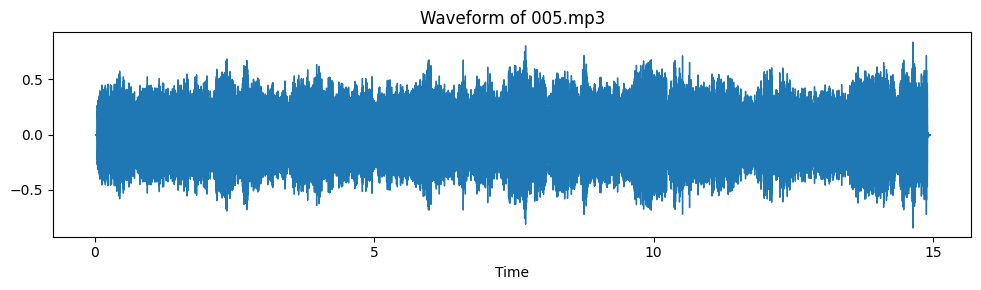

--- STAGE 2: MEL-FREQUENCY CEPSTRAL COEFFICIENTS (MFCCs) ---
MFCCs map the sound spectrum to how the human ear perceives pitch (Mel scale).


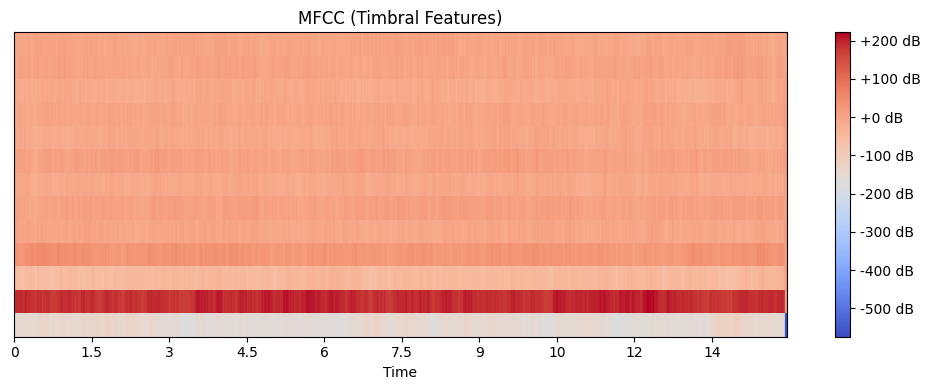

--- STAGE 3: CHROMAGRAM (HARMONIC CONTENT) ---
Chroma features fold the entire sound spectrum into the 12 distinct musical pitch classes (C, C#, D, etc.).


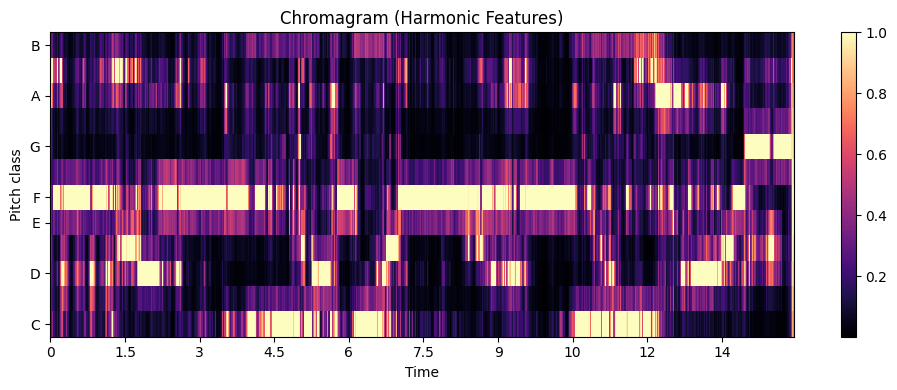

In [5]:
# --- VISUALIZATION CELL: AUDIO ---
# visualize the acoustic features we are extracting (MFCCs and Chroma)
import librosa
import librosa.display
import numpy as np

if os.path.exists(example_audio_path):
    print("--- STAGE 1: RAW AUDIO WAVEFORM ---")
    y, sr = librosa.load(example_audio_path, sr=None)
    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f'Waveform of {os.path.basename(example_audio_path)}')
    plt.tight_layout()
    plt.show()

    print("--- STAGE 2: MEL-FREQUENCY CEPSTRAL COEFFICIENTS (MFCCs) ---")
    print("MFCCs map the sound spectrum to how the human ear perceives pitch (Mel scale).")
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfccs, x_axis='time', sr=sr)
    plt.colorbar(format='%+2.0f dB')
    plt.title('MFCC (Timbral Features)')
    plt.tight_layout()
    plt.show()

    print("--- STAGE 3: CHROMAGRAM (HARMONIC CONTENT) ---")
    print("Chroma features fold the entire sound spectrum into the 12 distinct musical pitch classes (C, C#, D, etc.).")
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', sr=sr)
    plt.colorbar()
    plt.title('Chromagram (Harmonic Features)')
    plt.tight_layout()
    plt.show()
else:
    print("Audio path not found.")

### 4. Target Variables & Handling Missing Subjective Data
We implement the **Dual-Target** logic here.
* **Target A (Objective / Eerola Labels):** Merging from `mean_ratings_set1.csv`.
* **Target B (Subjective / Participant Reaction):** Extracted dynamically from the `800-807` + `901-909` triggers in the event TSVs. We apply **Scikit-Learn's KNNImputer** to predict missing data so we don't drop ~80% of our valid epochs, followed by **PCA** to reduce the 8 Likert scales down to 3 components (Valence, Energy, Tension).

In [ ]:
from eeg_utils import extract_subjective_ratings
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

# 1. Extract Target B (Subjective Ratings) from the events file
events_df = pd.read_csv(sub1_events, sep='\t')
ratings_df = extract_subjective_ratings(events_df)
print(f"Extracted ratings for {len(ratings_df)} music events in this run.")

# Show raw with missing NaN values
display(ratings_df.head(10))

# 2. Impute missing ratings using K-Nearest Neighbors
imputer = KNNImputer(n_neighbors=5, weights='distance')
# We only impute the Q columns
rating_cols = [f'Q{q}' for q in range(800, 808)]

# We will demonstrate imputation on just one run's data,
# but in practice, imputation is more robust over the entire cohort dataset combined.
ratings_imputed = ratings_df.copy()
ratings_imputed[rating_cols] = imputer.fit_transform(ratings_df[rating_cols])

print("\n--- AFTER KNN IMPUTATION ---")
display(ratings_imputed.head(10))

# 3. Apply PCA to reduce the 8 dimensions down to 3 Target Components
pca = PCA(n_components=3)
target_b_pca = pca.fit_transform(ratings_imputed[rating_cols])

ratings_imputed['PC1_Valence'] = target_b_pca[:, 0]
ratings_imputed['PC2_Energy'] = target_b_pca[:, 1]
ratings_imputed['PC3_Tension'] = target_b_pca[:, 2]

print("\n--- FINAL TARGET B (SUBJECTIVE PCs) ---")
display(ratings_imputed[['track_id', 'PC1_Valence', 'PC2_Energy', 'PC3_Tension']].head(10))